In [7]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("loss_by_turn_progress.csv")
df

,model,turn_progress_bin,brier_mean,brier_std,log_loss_mean,log_loss_std,n_samples
0,naive,0.0-0.1,0.109410,0.000004,0.376919,0.000011,162603
1,naive,0.1-0.2,0.109409,0.000003,0.376917,0.000009,160749
2,naive,0.2-0.3,0.109481,0.000065,0.377102,0.000166,161407
3,naive,0.3-0.4,0.109759,0.000219,0.377817,0.000561,160642
4,naive,0.4-0.5,0.110408,0.000308,0.379481,0.000789,159542
...,...,...,...,...,...,...,...
65,attention_mlp,0.5-0.6,0.080582,0.006109,0.260770,0.019330,159110
66,attention_mlp,0.6-0.7,0.076025,0.006807,0.245501,0.017655,154567
67,attention_mlp,0.7-0.8,0.069206,0.006608,0.223365,0.019305,149289
68,attention_mlp,0.8-0.9,0.060053,0.005985,0.194279,0.021362,144273


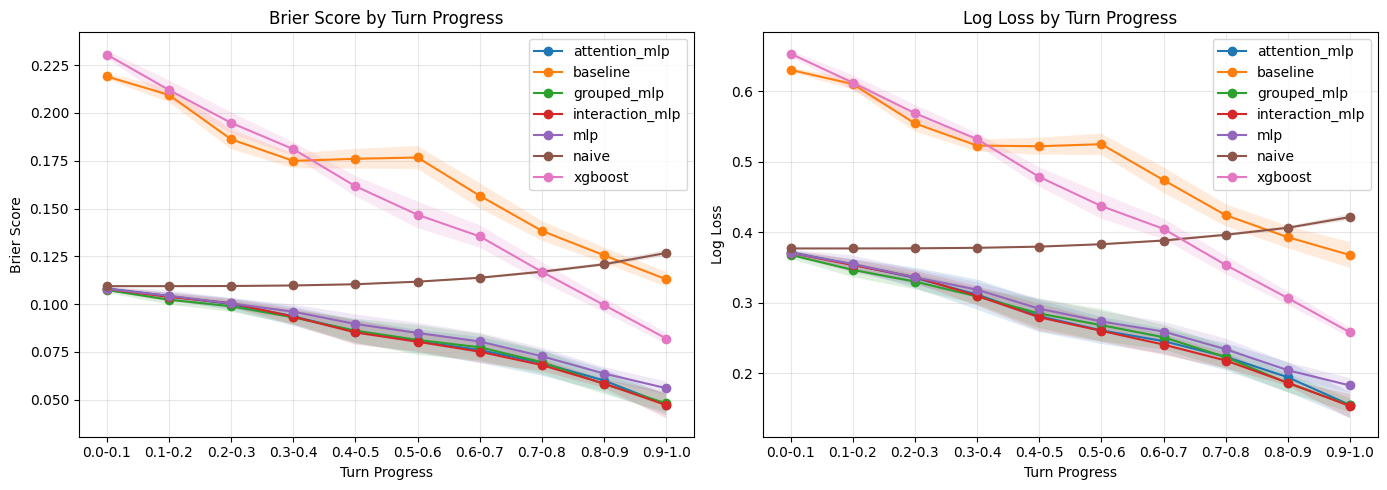

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for model, grp in df.groupby("model"):
    axes[0].plot(grp["turn_progress_bin"], grp["brier_mean"], marker="o", label=model)
    axes[0].fill_between(
        grp["turn_progress_bin"],
        grp["brier_mean"] - grp["brier_std"],
        grp["brier_mean"] + grp["brier_std"],
        alpha=0.15,
    )

axes[0].set_xlabel("Turn Progress")
axes[0].set_ylabel("Brier Score")
axes[0].set_title("Brier Score by Turn Progress")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

for model, grp in df.groupby("model"):
    axes[1].plot(grp["turn_progress_bin"], grp["log_loss_mean"], marker="o", label=model)
    axes[1].fill_between(
        grp["turn_progress_bin"],
        grp["log_loss_mean"] - grp["log_loss_std"],
        grp["log_loss_mean"] + grp["log_loss_std"],
        alpha=0.15,
    )

axes[1].set_xlabel("Turn Progress")
axes[1].set_ylabel("Log Loss")
axes[1].set_title("Log Loss by Turn Progress")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()